# Previsão de demanda de bicicletas compartilhadas em Seul com MLP

**Integrantes da equipe:** Gabriel Albuquerque Alencar, Alberto Eduardo Acosta, Davi Maciel Corrêa

**Disciplina:** Inteligência Computacional / Machine Learning — Profa. Polyana Santos Fonseca Nascimento

## Declaração de uso de IA Generativa

- **Ferramenta utilizada:** Claude (Anthropic), via Claude Code.
- **Finalidade do uso:** apoio na escrita do código e da documentação em Markdown deste notebook: análise exploratória, pipeline de pré-processamento, MLP, Random Search, TPE (Optuna), análises de sensibilidade e avaliação final.
- **Extensão aproximada da contribuição:** a IA gerou a maior parte do código e dos textos, a partir de um plano de execução definido com a equipe. As decisões de modelagem foram propostas pela IA e devem ser compreendidas e defendidas por cada integrante.
- **Medidas de validação:** todo o notebook é executado de ponta a ponta com sementes fixas; verificações automáticas (`assert`) garantem que treino e teste não compartilham dias; o conjunto de teste só é usado na avaliação final; os resultados e gráficos são conferidos e interpretados pela equipe.

> O arquivo `SeoulBikeData.csv` é o backup original e nunca é sobrescrito. A limpeza inicial (remoção de `Functioning Day = No` e criação de `IsWeekend`) está documentada em `preprocessing.ipynb` e gerou `SeoulBikeData_treated.csv`, que é a entrada deste notebook.

## 1. Dataset e justificativa

- **Dataset:** *Seoul Bike Sharing Demand* (UCI Machine Learning Repository / Kaggle), com uma observação por hora ao longo de um ano (dez/2017 a nov/2018).
- **Problema:** **regressão**. O alvo é `Rented Bike Count`, o número de bicicletas alugadas por hora.
- **Preditores:** hora do dia, variáveis climáticas (temperatura, umidade, vento, visibilidade, radiação solar, chuva, neve), estação do ano, feriado e fim de semana.
- **Motivação:** prever demanda horária ajuda a operadora a redistribuir bicicletas entre estações. O problema mistura efeitos sazonais, cíclicos (hora) e climáticos, com relações não lineares que justificam uma MLP.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="IProgress not found")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

SEED = 42
TARGET = "Rented Bike Count"
DATA_PATH = "SeoulBikeData_treated.csv"

## 2. Análise inicial dos dados

O arquivo tratado já não tem valores ausentes nem registros com o sistema fechado. Confirmamos o formato, os tipos e a ausência de nulos antes de explorar.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
print(df.shape)
print("Nulos:", int(df.isnull().sum().sum()), "| Dias distintos:", df["Date"].nunique())
df.head()

(8465, 14)
Nulos: 0 | Dias distintos: 353


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,IsWeekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,0


In [3]:
df.drop(columns="Date").describe().T[["mean", "std", "min", "50%", "max"]].round(2)

,mean,std,min,50%,max
Rented Bike Count,729.16,642.35,2.0,542.00,3556.00
Hour,11.51,6.92,0.0,12.00,23.00
Temperature(°C),12.77,12.10,-17.8,13.50,39.40
Humidity(%),58.15,20.48,0.0,57.00,98.00
Wind speed (m/s),1.73,1.03,0.0,1.50,7.40
Visibility (10m),1433.87,609.05,27.0,1690.00,2000.00
Dew point temperature(°C),3.94,13.24,-30.6,4.70,27.20
Solar Radiation (MJ/m2),0.57,0.87,0.0,0.01,3.52
Rainfall(mm),0.15,1.13,0.0,0.00,35.00
Snowfall (cm),0.08,0.44,0.0,0.00,8.80


### 2.1 Variável-alvo

A demanda é sempre positiva e assimétrica à direita: poucas horas concentram volumes muito altos. Comparamos a assimetria (*skewness*) do alvo original com duas transformações candidatas, `sqrt` e `log1p`.

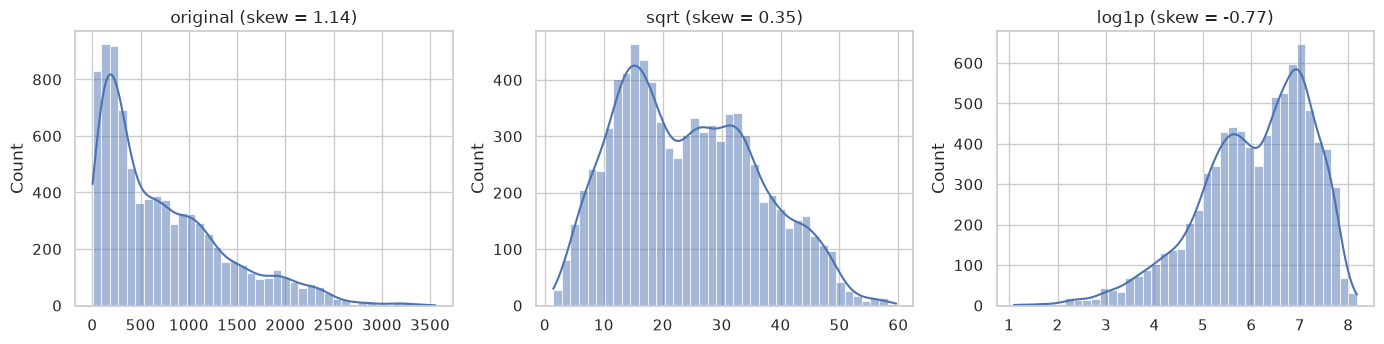

In [4]:
transforms = {"original": lambda s: s, "sqrt": np.sqrt, "log1p": np.log1p}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (name, fn) in zip(axes, transforms.items()):
    values = fn(df[TARGET])
    sns.histplot(values, bins=40, kde=True, ax=ax)
    ax.set_title(f"{name} (skew = {values.skew():.2f})")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

`sqrt` aproxima bem a simetria (skew 0,35), enquanto `log1p` supercorrige para o outro lado (−0,77). A transformação do alvo será escolhida experimentalmente na etapa da MLP base. Qualquer que seja ela, as métricas serão sempre reportadas **na escala original** (bicicletas/hora).

### 2.2 Padrões de demanda

A demanda depende fortemente da hora (picos de deslocamento às 8h e 18h), da estação e da chuva. A curva horária é cíclica, o que orienta a codificação de `Hour` mais adiante.

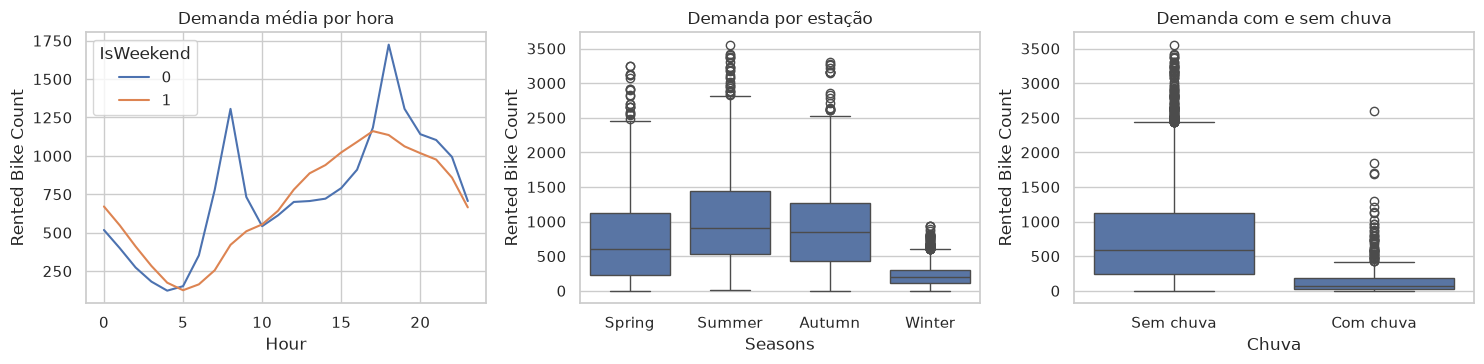

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
sns.lineplot(data=df, x="Hour", y=TARGET, hue="IsWeekend", errorbar=None, ax=axes[0])
axes[0].set_title("Demanda média por hora")
sns.boxplot(data=df, x="Seasons", y=TARGET, order=["Spring", "Summer", "Autumn", "Winter"], ax=axes[1])
axes[1].set_title("Demanda por estação")
rain = df.assign(Chuva=np.where(df["Rainfall(mm)"] > 0, "Com chuva", "Sem chuva"))
sns.boxplot(data=rain, x="Chuva", y=TARGET, ax=axes[2])
axes[2].set_title("Demanda com e sem chuva")
plt.tight_layout()
plt.show()

- **Hora:** em dias úteis há dois picos (8h e 18h), típicos de deslocamento casa-trabalho; no fim de semana há uma curva única e mais suave. A interação hora × fim de semana é um padrão que a MLP deve capturar.
- **Estação:** o inverno tem demanda muito menor.
- **Chuva:** horas com chuva derrubam a demanda.

### 2.3 Escalas e valores atípicos

Os atributos têm escalas muito diferentes (visibilidade na casa dos milhares, chuva e neve em décimos), o que exige padronização para uma MLP. Contamos os valores fora de 1,5×IQR de cada atributo numérico contínuo.

In [6]:
NUMERIC = ["Temperature(°C)", "Humidity(%)", "Wind speed (m/s)", "Visibility (10m)",
           "Solar Radiation (MJ/m2)", "Rainfall(mm)", "Snowfall (cm)"]
q1, q3 = df[NUMERIC].quantile(0.25), df[NUMERIC].quantile(0.75)
iqr = q3 - q1
outliers = ((df[NUMERIC] < q1 - 1.5 * iqr) | (df[NUMERIC] > q3 + 1.5 * iqr)).mean().mul(100).round(1)
pd.DataFrame({"% fora de 1.5×IQR": outliers, "% zeros": (df[NUMERIC] == 0).mean().mul(100).round(1)})

,% fora de 1.5×IQR,% zeros
Temperature(°C),0.0,0.2
Humidity(%),0.0,0.2
Wind speed (m/s),1.8,0.8
Visibility (10m),0.0,0.0
Solar Radiation (MJ/m2),7.3,49.0
Rainfall(mm),6.1,93.9
Snowfall (cm),5.2,94.8


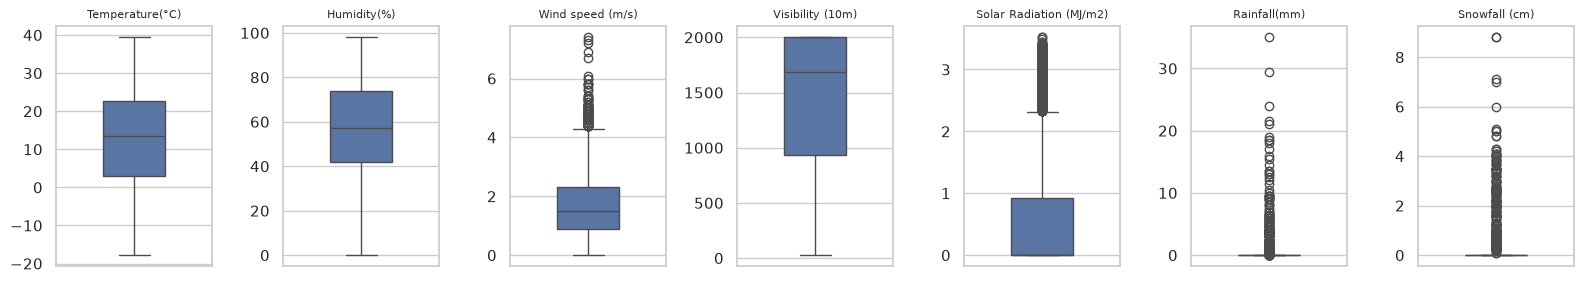

In [7]:
fig, axes = plt.subplots(1, len(NUMERIC), figsize=(16, 3))
for ax, col in zip(axes, NUMERIC):
    sns.boxplot(y=df[col], ax=ax, width=0.4)
    ax.set_ylabel("")
    ax.set_title(col, fontsize=8)
plt.tight_layout()
plt.show()

**Decisão sobre atípicos:** `Rainfall` e `Snowfall` são quase sempre zero (94% e 95%), então os poucos valores altos são eventos climáticos reais, não erros. `Solar Radiation` tem 49% de zeros pela noite. **Mantemos todos os valores**: removê-los eliminaria justamente as horas de baixa demanda que o modelo precisa aprender. A padronização (`StandardScaler`) resolve a diferença de escalas.

### 2.4 Correlações e redundância

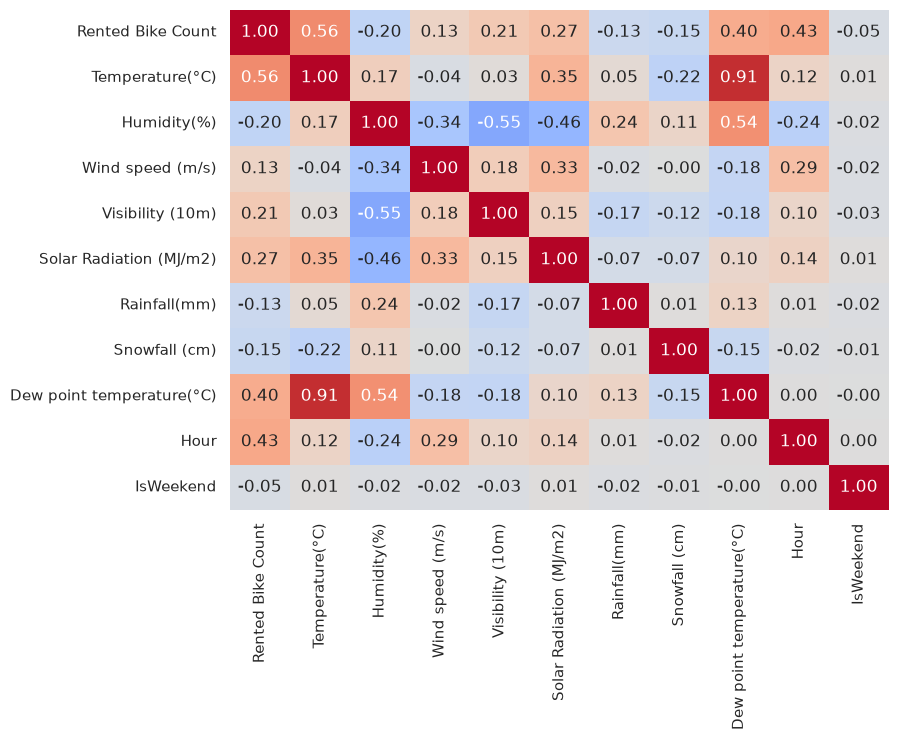

In [8]:
corr = df[[TARGET] + NUMERIC + ["Dew point temperature(°C)", "Hour", "IsWeekend"]].corr()
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, cbar=False)
plt.show()

`Temperature` e `Dew point temperature` têm correlação de 0,91: carregam praticamente a mesma informação. **Decisão:** remover `Dew point temperature`, mantendo `Temperature`, que tem correlação maior com o alvo e interpretação mais direta. Isso reduz a colinearidade sem perda relevante de informação. `Hour` aparece com correlação linear moderada com o alvo, mas o efeito real é cíclico e não linear, tratado na codificação seno/cosseno.

## 3. Conjunto de teste (holdout) e validação cruzada

### 3.1 Separação treino/teste

Os registros são horários: horas vizinhas do mesmo dia são muito parecidas (mesmo clima, mesma estação). Um sorteio aleatório por linha colocaria horas do mesmo dia em treino e em teste, e o teste ficaria otimista por **vazamento**. Um corte temporal também não serve: com apenas um ano de dados, o teste cairia em uma estação que o treino nunca viu.

**Decisão:** separar por **dia inteiro**, agrupando por `Date`, e **estratificar por estação** para que o teste tenha a mesma mistura de estações do treino (um sorteio simples de 71 dias deixou inverno sobrerrepresentado). Usamos `StratifiedGroupKFold` com 5 partes e tomamos uma delas, cerca de 20% dos dias, como teste. Esse conjunto só volta a ser usado na avaliação final (seção 9).

In [9]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

FEATURES = NUMERIC + ["Hour", "IsWeekend", "Seasons", "Holiday"]

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(splitter.split(df, df["Seasons"], groups=df["Date"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

X_train, y_train, groups_train = train_df[FEATURES], train_df[TARGET], train_df["Date"]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

assert set(train_df["Date"]).isdisjoint(test_df["Date"])

pd.DataFrame({
    "linhas": [len(train_df), len(test_df)],
    "dias": [train_df["Date"].nunique(), test_df["Date"].nunique()],
    "alvo médio": [y_train.mean(), y_test.mean()],
    "alvo mediano": [y_train.median(), y_test.median()],
    "alvo desvio": [y_train.std(), y_test.std()],
}, index=["treino", "teste"]).round(1)

,linhas,dias,alvo médio,alvo mediano,alvo desvio
treino,6761,282,731.1,547.0,640.7
teste,1704,71,721.5,531.5,649.0


In [10]:
season_share = pd.concat([train_df["Seasons"].value_counts(normalize=True).rename("treino"),
                          test_df["Seasons"].value_counts(normalize=True).rename("teste")], axis=1)
season_share.mul(100).round(1)

,treino,teste
Seasons,,
Summer,25.9,26.8
Winter,25.6,25.4
Spring,25.6,25.4
Autumn,23.0,22.5


A estratificação mantém a proporção de estações próxima nos dois conjuntos e o alvo com escala parecida, então o holdout é representativo.

### 3.2 Estratégia de validação cruzada

A validação cruzada usa **apenas o conjunto de treino**, com `StratifiedGroupKFold` de 5 folds embaralhados, agrupados por dia e estratificados por estação. Os folds são gerados **uma única vez** e reutilizados em todos os experimentos (Random Search, TPE, sensibilidade), garantindo comparações justas.

In [11]:
N_SPLITS = 5
cv_splits = list(StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED).split(X_train, X_train["Seasons"], groups_train))

pd.DataFrame([
    {"fold": k + 1, "treino": len(tr), "validação": len(va), "dias na validação": groups_train.iloc[va].nunique()}
    for k, (tr, va) in enumerate(cv_splits)
]).set_index("fold")

,treino,validação,dias na validação
fold,,,
1,5393,1368,57
2,5417,1344,56
3,5400,1361,57
4,5417,1344,56
5,5417,1344,56


## 4. Construção da MLP

### 4.1 Pré-processamento dentro do pipeline

Todas as transformações que aprendem parâmetros dos dados entram em um `Pipeline`, ajustado somente com o treino de cada fold, para não vazar informação da validação:

- `Hour` vira `sin` e `cos` (a hora 23 é vizinha da hora 0);
- atributos contínuos passam por `StandardScaler`;
- `Seasons` e `Holiday` recebem *one-hot*; `IsWeekend` já é binária;
- `Date` e `Dew point temperature` ficam fora, conforme a análise exploratória;
- o alvo é transformado (`sqrt`, `log1p` ou nenhuma) dentro de um `TransformedTargetRegressor`, que devolve as previsões à escala original.

**Métrica principal: RMSE** (bicicletas/hora), que penaliza mais os erros grandes, importantes para dimensionar a frota. MAE e R² são complementares.

In [12]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

MAX_ITER = 300
N_JOBS = N_SPLITS
SCORING = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}
TARGET_TRANSFORMS = {"original": (None, None), "sqrt": (np.sqrt, np.square), "log1p": (np.log1p, np.expm1)}


def add_hour_cycle(X):
    X = X.copy()
    X["hour_sin"] = np.sin(2 * np.pi * X["Hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["Hour"] / 24)
    return X.drop(columns="Hour")


def build_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), NUMERIC),
        ("cat", OneHotEncoder(drop="if_binary"), ["Seasons", "Holiday"]),
        ("pass", "passthrough", ["IsWeekend", "hour_sin", "hour_cos"]),
    ])


def build_model(p, seed=SEED, target_transform=None):
    func, inverse = TARGET_TRANSFORMS[target_transform or TARGET_TRANSFORM]
    mlp = MLPRegressor(
        hidden_layer_sizes=(p["n_units"],) * p["n_layers"],
        activation=p["activation"],
        solver=p["solver"],
        learning_rate_init=p["learning_rate"],
        batch_size=p["batch_size"],
        early_stopping=True,
        n_iter_no_change=p["patience"],
        max_iter=MAX_ITER,
        random_state=seed,
    )
    pipeline = Pipeline([
        ("hour", FunctionTransformer(add_hour_cycle)),
        ("prep", build_preprocessor()),
        ("mlp", mlp),
    ])
    return TransformedTargetRegressor(regressor=pipeline, func=func, inverse_func=inverse, check_inverse=False)


memory = joblib.Memory(".cache", verbose=0)


@memory.cache
def cached_cross_validate(p, seed, target_transform, max_iter, X, y, splits):
    return cross_validate(build_model(p, seed, target_transform), X, y, cv=splits,
                          scoring=SCORING, return_train_score=True, n_jobs=N_JOBS)


def cv_evaluate(p, seed=SEED, target_transform=None):
    scores = cached_cross_validate(p, seed, target_transform or TARGET_TRANSFORM, MAX_ITER, X_train, y_train, cv_splits)
    return pd.Series({
        "val_rmse": -scores["test_rmse"].mean(),
        "val_rmse_std": scores["test_rmse"].std(),
        "val_mae": -scores["test_mae"].mean(),
        "val_r2": scores["test_r2"].mean(),
        "train_rmse": -scores["train_rmse"].mean(),
        "train_r2": scores["train_r2"].mean(),
    })

### 4.2 MLP base e escolha da transformação do alvo

Treinamos uma MLP simples e razoável (2 camadas de 64 neurônios, ReLU, Adam, *learning rate* 1e-3, lote de 64, paciência 10) com cada transformação do alvo, avaliando por validação cruzada. A transformação com menor RMSE é fixada para todo o restante do trabalho.

In [13]:
BASELINE = {"n_layers": 2, "n_units": 64, "activation": "relu", "solver": "adam",
            "learning_rate": 1e-3, "batch_size": 64, "patience": 10}

transform_results = pd.DataFrame({name: cv_evaluate(BASELINE, target_transform=name) for name in TARGET_TRANSFORMS}).T
TARGET_TRANSFORM = transform_results["val_rmse"].idxmin()
print("Transformação escolhida:", TARGET_TRANSFORM)
transform_results.round(3)

Transformação escolhida: sqrt


,val_rmse,val_rmse_std,val_mae,val_r2,train_rmse,train_r2
original,201.892,12.116,129.289,0.900,166.673,0.932
sqrt,193.015,13.452,121.862,0.908,147.733,0.946
log1p,227.706,16.483,143.657,0.872,190.652,0.911


A raiz quadrada do alvo vence (RMSE ≈ 193 contra 202 sem transformação). O `log1p` fica pior, pois otimiza erro relativo e subestima os picos de demanda, justamente o que o RMSE em escala original penaliza. A **raiz quadrada** fica fixa daqui em diante.

### 4.3 Comportamento do treino da MLP base

Ajustamos o modelo base em todo o treino (o teste continua intocado) e observamos a curva de perda e a pontuação R² da fatia de validação interna usada pelo *early stopping*.

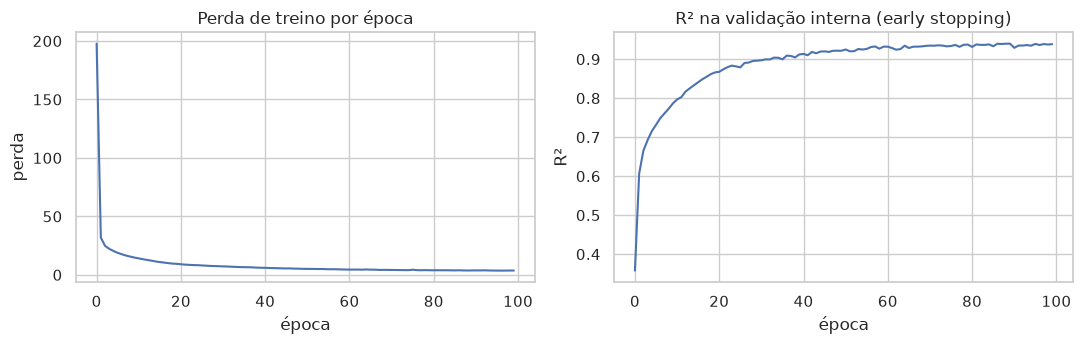

Épocas executadas: 100


In [14]:
base_model = build_model(BASELINE).fit(X_train, y_train)
base_mlp = base_model.regressor_.named_steps["mlp"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(base_mlp.loss_curve_)
axes[0].set(title="Perda de treino por época", xlabel="época", ylabel="perda")
axes[1].plot(base_mlp.validation_scores_)
axes[1].set(title="R² na validação interna (early stopping)", xlabel="época", ylabel="R²")
plt.tight_layout()
plt.show()
print("Épocas executadas:", base_mlp.n_iter_)

A perda cai rapidamente e estabiliza, e o R² de validação interna chega perto de 0,94 sem sinais de divergência. O modelo base já explica cerca de 91% da variância em validação cruzada (R² ≈ 0,91, RMSE ≈ 193 bicicletas/hora), com R² de treino um pouco maior (≈ 0,95). Esse é o ponto de referência a ser melhorado pelas buscas de hiperparâmetros.